### LOADING AND CONFIGURING

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

PROCESSED_PATH = r'../../../processed_data' 
MODEL_SAVE_PATH = r'./model_checkpoints'

if not os.path.exists(MODEL_SAVE_PATH):
    os.makedirs(MODEL_SAVE_PATH)

print("Loading FD004 Specialist 1 (Cluster 1) Arrays...")
X_train = np.load(os.path.join(PROCESSED_PATH, 'X_train_FD004_c1.npy'))
y_train = np.load(os.path.join(PROCESSED_PATH, 'y_train_FD004_c1.npy'))

print(f"Specialist 1 Train Shape: {X_train.shape}")

Loading FD004 Specialist 1 (Cluster 1) Arrays...
Specialist 1 Train Shape: (22699, 60, 24)


### ATTENTION LAYER

In [2]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

### BUILDING MODEL

In [3]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)
    x = LSTM(128, return_sequences=True, name='lstm_layer')(inputs)
    x = Dropout(0.3)(x)  # Heavy dropout is back to fight the noise
    x = Attention(name='attention_layer')(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='linear')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_model((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse', metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 60, 24)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_layer (LSTM)                    │ (None, 60, 128)             │          78,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer (Attention)          │ (None, 128)                 │             188 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 88,893 (347.24 KB)

 Trainable params: 88,893 (347.24 KB)

 Non-trainable params: 0 (0.00 B)

### TRAINING MODEL

In [4]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("\nStarting FD004 Global Training...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2, 
    epochs=80, 
    batch_size=200, 
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Starting FD004 Global Training...
Epoch 1/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 5520.2876 - mae: 62.6167 - val_loss: 1817.1766 - val_mae: 37.9420 - learning_rate: 0.0010
Epoch 2/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 1814.0247 - mae: 37.3010 - val_loss: 1771.3577 - val_mae: 37.4350 - learning_rate: 0.0010
Epoch 3/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 1768.1805 - mae: 36.6533 - val_loss: 1781.9807 - val_mae: 37.5968 - learning_rate: 0.0010
Epoch 4/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 1783.2161 - mae: 36.9681 - val_loss: 1785.3024 - val_mae: 37.6352 - learning_rate: 0.0010
Epoch 5/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 1790.3010 - mae: 36.9850 - val_loss: 1772.4589 - val_mae: 37.4793 - learning_rate: 0.0010
Epoch 6/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 1802.1389 - mae: 37.1673 - val_loss: 1782.8485 - val_mae: 37.6057 - learning_rate: 0.0010
Epoch 7/80
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1746.1893 -

### SAVING MODEL

In [5]:
model_path = os.path.join(MODEL_SAVE_PATH, 'specialist_1_fd004.keras')
model.save(model_path)
print(f"\nSpecialist 1 Model saved to {model_path}")


Specialist 1 Model saved to ./model_checkpoints\specialist_1_fd004.keras


### VISUALISING

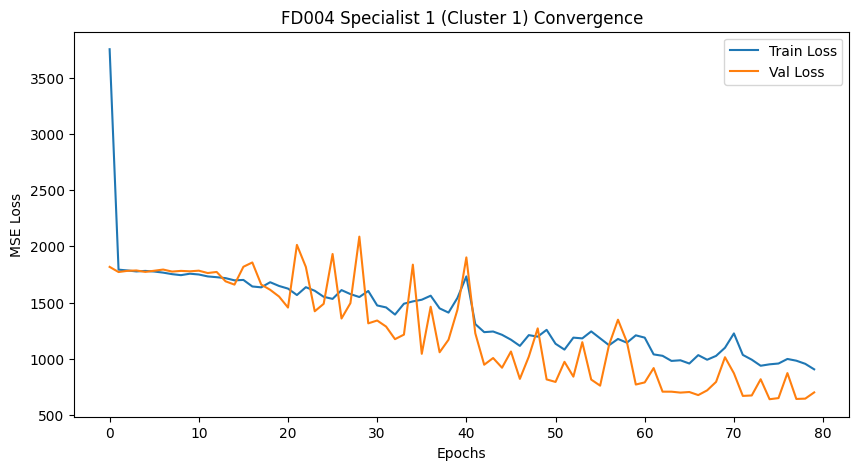

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('FD004 Specialist 1 (Cluster 1) Convergence')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()